# 클러스터링

## 클러스터링 알고리즘 유형

### K-평균 군집화

#### 파이토치로 K-평균 군집화 예제 구현하기

##### 라이브러리 불러오기

In [1]:
!pip install kmeans-pytorch

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from kmeans_pytorch import kmeans, kmeans_predict

##### 데이터셋 불러오기

In [5]:
from google.colab import files # 데이터 불러오기
file_uploaded = files.upload()

Saving iris.csv to iris.csv


In [6]:
df = pd.read_csv('iris.csv')
df.info()
print('----------------------------------------')
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
----------------------------------------
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            .

##### 워드 임베딩

In [7]:
data = pd.get_dummies(df, columns=['Species'])
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
0,1,5.1,3.5,1.4,0.2,True,False,False
1,2,4.9,3.0,1.4,0.2,True,False,False
2,3,4.7,3.2,1.3,0.2,True,False,False
3,4,4.6,3.1,1.5,0.2,True,False,False
4,5,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,False,False,True
146,147,6.3,2.5,5.0,1.9,False,False,True
147,148,6.5,3.0,5.2,2.0,False,False,True
148,149,6.2,3.4,5.4,2.3,False,False,True


##### 데이터셋 분리

In [8]:
from sklearn.model_selection import train_test_split

x, y = train_test_split(data, test_size=0.2, random_state=123)

##### GPU 사용 설정

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

##### 특성 스케일링

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
y_scaled = scaler.fit(y).transform(y)

##### 데이터를 텐서로 변경

In [11]:
x = torch.from_numpy(X_scaled)
y = torch.from_numpy(y_scaled)

##### 훈련과 테스트 데이터셋 크기

In [12]:
print(x.size())
print(y.size())
print(x)

torch.Size([120, 8])
torch.Size([30, 8])
tensor([[ 1.2880,  1.8911, -0.5490,  1.3238,  0.9151, -0.6677, -0.7609,  1.4412],
        [ 1.0315,  0.1616, -1.9169,  0.6849,  0.3742, -0.6677, -0.7609,  1.4412],
        [-1.0676, -1.4443,  0.3629, -1.2900, -1.3839,  1.4977, -0.7609, -0.6939],
        [-1.7440, -0.9502,  1.0468, -1.4061, -1.3839,  1.4977, -0.7609, -0.6939],
        [-0.2980,  0.1616, -1.9169,  0.1041, -0.3020, -0.6677,  1.3143, -0.6939],
        [ 0.4251, -1.0737, -1.6889, -0.3025, -0.3020, -0.6677,  1.3143, -0.6939],
        [ 1.3113,  2.5087,  1.7307,  1.4981,  1.0503, -0.6677, -0.7609,  1.4412],
        [-1.6274, -0.5796,  1.9587, -1.2319, -1.1134,  1.4977, -0.7609, -0.6939],
        [-1.3708, -0.5796,  1.9587, -1.4642, -1.1134,  1.4977, -0.7609, -0.6939],
        [ 0.1685, -0.0854, -0.7770,  0.0460, -0.0316, -0.6677,  1.3143, -0.6939],
        [-0.3446, -1.0737, -2.3728, -0.1864, -0.3020, -0.6677,  1.3143, -0.6939],
        [-0.9277, -1.0737,  0.3629, -1.5223, -1.3839,  1.

##### K-평균 군집화 적용

In [15]:
num_clusters = 3
cluster_ids_x, cluster_centers = kmeans(
    X=x, num_clusters=num_clusters, distance='euclidean', device=device
)

running k-means on cuda:0..


[running kmeans]: 5it [00:00,  7.15it/s, center_shift=0.000000, iteration=5, tol=0.000100]


##### 클러스터 ID와 클러스터 중심에 대한 값 확인

In [16]:
print(cluster_ids_x)
print(cluster_centers)

tensor([2, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 0, 0, 2, 0, 0, 0,
        0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 1, 0, 2, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 0,
        0, 0, 0, 0, 0, 2, 0, 2, 1, 0, 0, 0, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 2])
tensor([[-0.5565, -0.4271,  0.0899, -0.4918, -0.5241,  0.3215,  0.3664, -0.6939],
        [ 1.0905,  0.2110, -0.8682,  0.7817,  0.8430, -0.6677, -0.7609,  1.4412],
        [ 1.1967,  1.3094,  0.2394,  1.1714,  1.2419, -0.6677, -0.7609,  1.4412]])


##### K-평균 군집화 예측

In [17]:
cluster_ids_y = kmeans_predict(
    y, cluster_centers, 'euclidean', device=device
)

predicting on cuda:0..


##### 테스트 데이터셋에 대한 클러스터 ID

In [18]:
print(cluster_ids_y)

tensor([0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 0, 0, 1, 2, 0])


##### 예측 결과 그래프로 확인

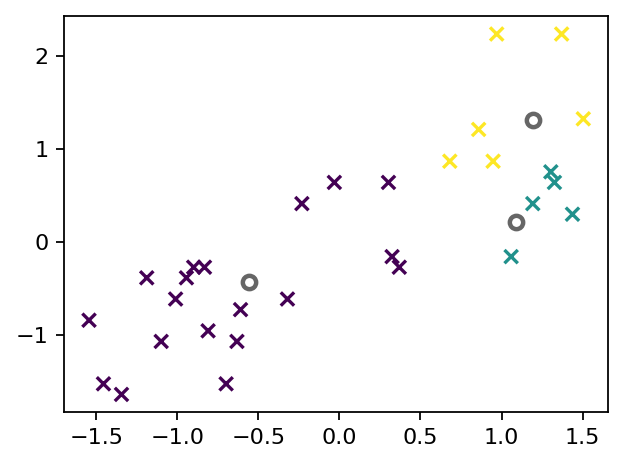

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3), dpi=160)
plt.scatter(y[:, 0], y[:, 1],c=cluster_ids_y, cmap='viridis', marker='x')

plt.scatter(
    cluster_centers[:, 0], cluster_centers[:, 1],
    c='white',
    alpha=0.6,
    edgecolors='black',
    linewidths=2
)

plt.tight_layout()
plt.show()

### 가우시안 혼합 모델

##### 라이브러리 호출 및 데이터 로딩

In [22]:
from google.colab import files # 데이터 불러오기
file_uploaded = files.upload()

Saving data.npy to data.npy


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
X_train = np.load('data.npy')

##### GMM 생성

[[1.60718016 1.35251723]
 [3.04641134 3.10654272]]


[[[ 0.74995307 -0.5010097 ]
  [-0.5010097   0.74377694]]

 [[ 0.83656079  0.37865596]
  [ 0.37865596  0.72727426]]]


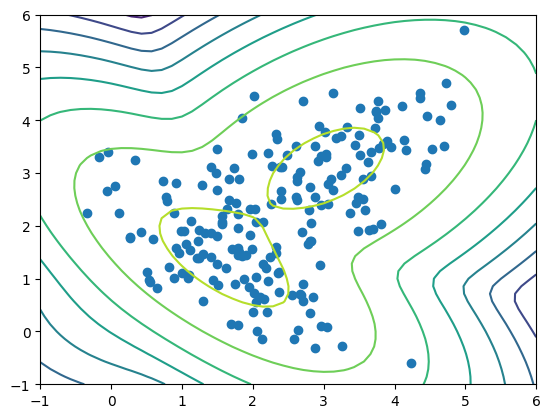

In [24]:
gmm = GaussianMixture(n_components=2)
gmm.fit(X_train)

print(gmm.means_)
print('\n')
print(gmm.covariances_)

X, Y = np.meshgrid(np.linspace(-1, 6), np.linspace(-1,6))
XX = np.array([X.ravel(), Y.ravel()]).T
Z = gmm.score_samples(XX)
Z = Z.reshape((50,50))

plt.contour(X, Y, Z)
plt.scatter(X_train[:, 0], X_train[:, 1])
plt.show()

### 자기 조직화 지도

#### 자기 조직화 지도를 예제로 살펴보기

In [25]:
!pip install MiniSom

  Preparing metadata (setup.py) ... done
  Created wheel for MiniSom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=5847cb7d83926bad4abdd850d10b300ddda326453354d20b1678590555abbafd
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built MiniSom


##### 라이브러리 호출 및 데이터셋 내려받기

In [26]:
import numpy as np
from sklearn.datasets import load_digits
from minisom import MiniSom
from pylab import plot,axis,show,pcolor,colorbar,bone

digits = load_digits()
data = digits.data
labels = digits.target

##### 훈련 데이터셋을 MiniSom 알고리즘에 적용

SOM 초기화.

. SOM 진행 종료


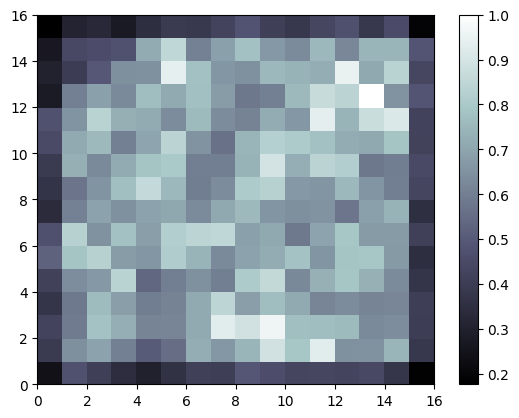

In [27]:
som = MiniSom(16,16,64,sigma=1.0,learning_rate=0.5)
som.random_weights_init(data)
print("SOM 초기화.")
som.train_random(data,10000)
print("\n. SOM 진행 종료")

bone()
pcolor(som.distance_map().T)
colorbar()

##### 클래스에 대해 레이블 설정 및 색상 할당

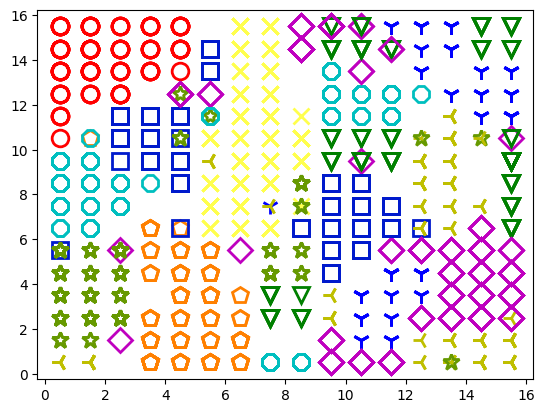

In [28]:
labels[labels == '0'] = 0
labels[labels == '1'] = 1
labels[labels == '2'] = 2
labels[labels == '3'] = 3
labels[labels == '4'] = 4
labels[labels == '5'] = 5
labels[labels == '6'] = 6
labels[labels == '7'] = 7
labels[labels == '8'] = 8
labels[labels == '9'] = 9

markers = ['o', 'v', '1', '3', '8', 's', 'p', 'x', 'D', '*']
colors = ["r", "g", "b", "y", "c", (0,0.1,0.8), (1,0.5,0), (1,1,0.3), "m", (0.4,0.6,0)]
for cnt, xx in enumerate(data):
   w = som.winner(xx)
   plot(w[0]+.5,w[1]+.5,markers[labels[cnt]],
   markerfacecolor='None', markeredgecolor=colors[labels[cnt]],
   markersize=12, markeredgewidth=2)
show()